# Cflows tutorial

A worked example on the in-vivo branch: the GAGA latent space, trajectories from the
fitted flow model, the growth filter, decoding to gene space, and Granger causality,
using the same functions as `run.py`. For the full published results, run the scripts
(`python run.py all`).

Unpack the data bundle under `data/`, activate the `cflows` environment, and run this
notebook from the repository root. The Granger step takes several minutes.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    raise SystemExit("run this notebook from the repository root")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from common import DATA, strip_xy
from gaga import Autoencoder
from flow import ODEFunc, GrowthRateModel, infer
from granger import do_granger
from trajectories import build_dataset
from growth_filter import gmm_threshold
from in_vivo import load_decoder, decode_selected, finalise_3d, cluster_trends

import matplotlib.pyplot as plt
%matplotlib inline

IN_DIR = DATA / "in_vivo"
T1_COLOR = "#E6A024"

## 1. The GAGA latent space

The fitted encoder maps the PCA coordinates of the cells into the 3-D latent space
in which the trajectories live.

In [2]:
adata = sc.read_h5ad(IN_DIR / "in_vivo.h5ad")
with (IN_DIR / "gaga_pca_scaler.pkl").open("rb") as handle:
    pca_scaler = pickle.load(handle)

gaga = Autoencoder(
    input_dim=adata.obsm["X_pca"].shape[1], latent_dim=3, hidden_dims=[256, 128, 64, 32]
)
gaga.load_state_dict(torch.load(IN_DIR / "gaga_model.pt", map_location="cpu"))
gaga.eval()

x_pca = pca_scaler.transform(np.asarray(adata.obsm["X_pca"], dtype=np.float32)).astype(np.float32)
with torch.no_grad():
    cells = gaga.encode(torch.from_numpy(x_pca)).numpy()

print(f"{adata.n_obs} cells x {adata.n_vars} genes  ->  latent {cells.shape}")

3389 cells x 36601 genes  ->  latent (3389, 3)


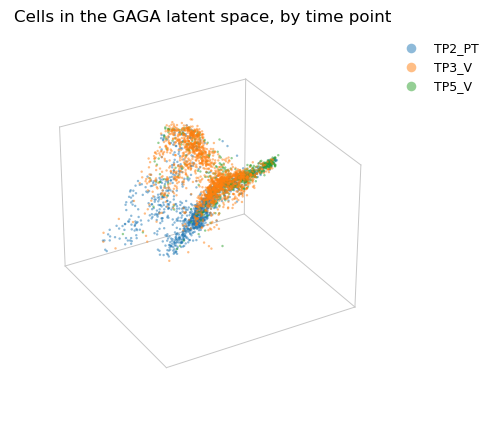

In [3]:
figure = plt.figure(figsize=(6, 5))
axis = figure.add_subplot(111, projection="3d")
for sample in adata.obs["sample"].cat.categories:
    keep = (adata.obs["sample"] == sample).to_numpy()
    axis.scatter(*cells[keep].T, s=3, alpha=0.5, label=sample, linewidths=0)
finalise_3d(axis)
axis.legend(fontsize=9, markerscale=4, loc="upper left", bbox_to_anchor=(0.98, 1.0), frameon=False)
axis.set_title("Cells in the GAGA latent space, by time point")
plt.show()

## 2. Trajectories from the fitted flow model

Integrating the fitted velocity field from the archived initial conditions with `dopri5`.

In [4]:
indices = json.loads((IN_DIR / "flow_initial_indices.json").read_text())["groups"]["T1"]["indices"]
frame = pd.read_csv(IN_DIR / "T1_flow_input.csv").sort_values("samples").reset_index(drop=True)
with (IN_DIR / "T1_flow_scaler.pkl").open("rb") as handle:
    traj_scaler = pickle.load(handle)

dataset = build_dataset(frame, traj_scaler)
x0 = dataset.get_initial_condition()[torch.as_tensor(indices, dtype=torch.long)]

ode = ODEFunc(input_dim=3, hidden_dim=32)
ode.load_state_dict(torch.load(IN_DIR / "T1_flow_model.pt", map_location="cpu"))
ode.eval()

times = torch.linspace(min(dataset.times), max(dataset.times), 100)
with torch.no_grad():
    scaled = infer(x0=x0, model=ode, t_seq=times)
scaled = scaled.permute(1, 0, 2).numpy()
T1 = traj_scaler.inverse_transform(scaled.reshape(-1, 3)).reshape(scaled.shape).astype(np.float32)

print("T1 latent trajectories (trajectory, time, latent dim):", T1.shape)

T1 latent trajectories (trajectory, time, latent dim): (500, 100, 3)


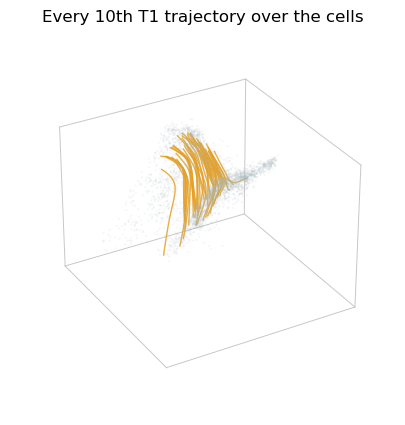

In [5]:
figure = plt.figure(figsize=(6, 5))
axis = figure.add_subplot(111, projection="3d")
axis.scatter(*cells.T, s=2, alpha=0.15, color="#B0BEC5", linewidths=0)
for path in T1[::10]:
    axis.plot(*path.T, color=T1_COLOR, linewidth=1.0, alpha=0.85)
finalise_3d(axis)
axis.set_title("Every 10th T1 trajectory over the cells")
plt.show()

## 3. The growth filter

The fitted growth model predicts a rate at each trajectory's starting point; a
two-component Gaussian mixture sets the threshold that selects the trajectories
carried into the analysis.

threshold 0.8793   to-grow 365 of 500


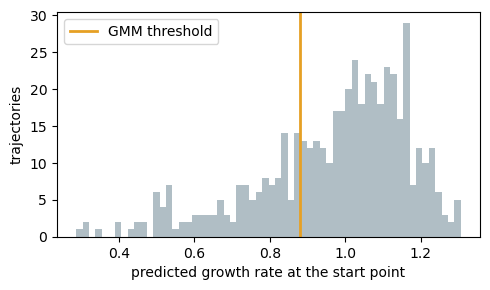

In [6]:
growth_model = GrowthRateModel(input_dim=3, hidden_dim=32, use_time=True)
growth_model.load_state_dict(torch.load(IN_DIR / "T1_growth_model.pt", map_location="cpu"))
growth_model.eval()

start = torch.tensor(traj_scaler.transform(T1[:, 0, :]), dtype=torch.float32)
t_start = torch.full((start.shape[0], 1), float(frame["samples"].min()), dtype=torch.float32)
with torch.no_grad():
    growth = growth_model(start, t_start).numpy().reshape(-1)

gmm = gmm_threshold(growth)
to_grow = growth >= gmm["threshold"]
print(f"threshold {gmm['threshold']:.4f}   to-grow {to_grow.sum()} of {len(to_grow)}")

figure, axis = plt.subplots(figsize=(5, 3))
axis.hist(growth, bins=60, color="#B0BEC5")
axis.axvline(gmm["threshold"], color=T1_COLOR, linewidth=2, label="GMM threshold")
axis.set_xlabel("predicted growth rate at the start point"); axis.set_ylabel("trajectories")
axis.legend(); plt.tight_layout(); plt.show()

## 4. Decoding to gene space

The decoder runs the latent coordinates back through the GAGA decoder and inverts the
PCA, giving an expression value per gene at every point along every trajectory. Only
genes in the PCA gene set (`highly_variable`) can be decoded.

decoded (trajectory, time, gene): (365, 100, 4126)


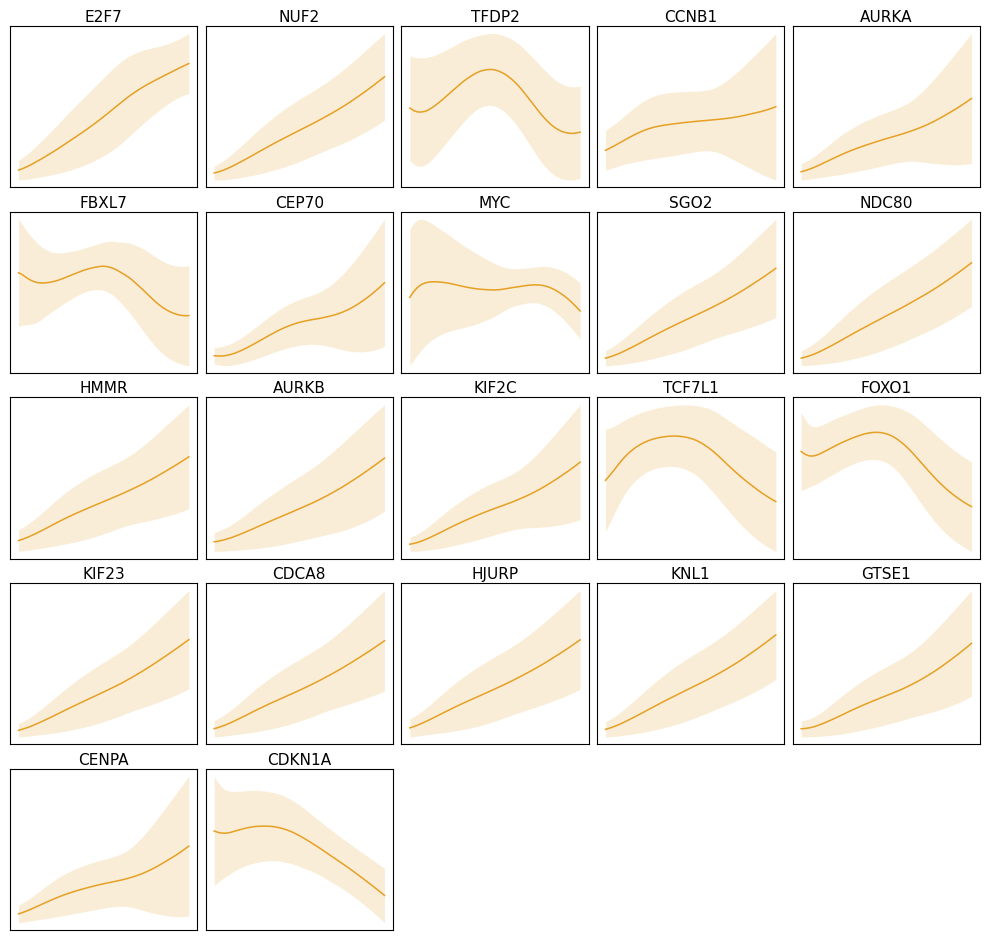

In [7]:
decoder, decoder_scaler, pcs, means = load_decoder(adata)

hvg = np.asarray(adata.var["highly_variable"], dtype=bool)
gene_index = np.flatnonzero(hvg)
genes = np.asarray(adata.var_names)[gene_index]

decoded = decode_selected(T1[to_grow], gene_index, decoder, decoder_scaler, pcs, means)
print("decoded (trajectory, time, gene):", decoded.shape)

shown = [g.strip() for g in (ROOT / "config/figure7f_T1_genes.txt").read_text().split() if g.strip()]
lookup = {gene: i for i, gene in enumerate(genes)}

columns = 5
rows = int(np.ceil(len(shown) / columns))
figure, axes = plt.subplots(rows, columns, figsize=(2.0 * columns, 1.9 * rows), squeeze=False)
for axis, gene in zip(axes.flat, shown):
    series = decoded[:, :, lookup[gene]]
    mean, sd = series.mean(axis=0), series.std(axis=0)
    axis.plot(mean, color=T1_COLOR, lw=1.1)
    axis.fill_between(np.arange(len(mean)), mean - sd, mean + sd,
                      color=T1_COLOR, alpha=0.18, linewidth=0)
    axis.set_title(gene, fontsize=11, pad=3)
    axis.set_xticks([]); axis.set_yticks([])
for axis in axes.flat[len(shown):]:
    axis.axis("off")
figure.tight_layout(h_pad=0.6, w_pad=0.6)
plt.show()

## 5. Granger causality

Trajectories are averaged, subsampled to 10 time points, and first-differenced before a
lag-1 test. The signed score is `-log(p + 2^-10) * sign(coef)`; the floor caps it at
`±6.93`. Genes are grouped into temporal clusters by when they peak, and a pair is
eligible only when the regulator peaks no later than its target.

A small block of regulators and targets is shown here. `python run.py in-vivo` writes
the complete matrices for T1 and T2.

In [8]:
clusters, _ = cluster_trends(decoded, genes, 4)
is_tf = set(np.asarray(adata.var_names)[np.asarray(adata.var["is_tf"], dtype=bool)])

ordered_tfs = [g for g in clusters.index if g in is_tf]
ordered_targets = list(clusters.index)
tf_names = ordered_tfs[:: max(1, len(ordered_tfs) // 12)][:12]
target_names = ordered_targets[:: max(1, len(ordered_targets) // 40)][:40]

subset = list(dict.fromkeys(tf_names + target_names))
frame = pd.DataFrame(decoded[:, :, [lookup[g] for g in subset]].mean(axis=0), columns=subset)
pvals, coefs = do_granger(frame.T, in_genes=tf_names, out_genes=target_names, n_jobs=-1)
signed = (-np.log(pvals + 2**-10)) * np.sign(coefs)
signed.index = [strip_xy(i) for i in signed.index]
signed.columns = [strip_xy(c) for c in signed.columns]
print(f"{signed.shape[0]} regulators x {signed.shape[1]} targets")

12 regulators x 40 targets


37% of these pairs are ineligible (regulator peaks after its target)


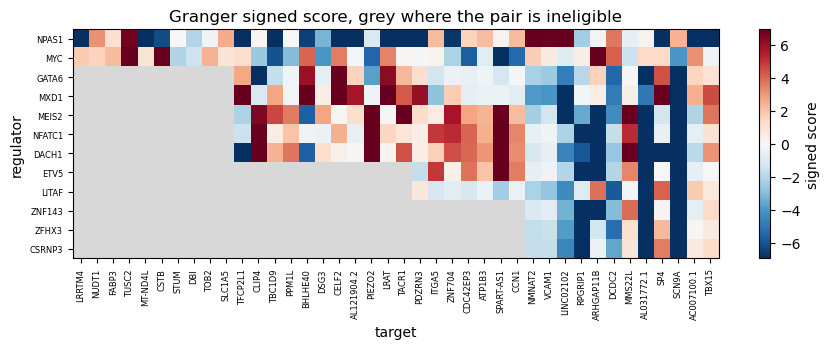

In [9]:
tf_cluster = clusters.loc[list(signed.index), "cluster"].astype(int).to_numpy()
target_cluster = clusters.loc[list(signed.columns), "cluster"].astype(int).to_numpy()
mask = tf_cluster[:, None] > target_cluster[None, :]
print(f"{mask.mean():.0%} of these pairs are ineligible (regulator peaks after its target)")

ceiling = -np.log(2**-10)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("0.85")
figure, axis = plt.subplots(figsize=(9, 3.6))
image = axis.imshow(np.ma.array(signed.to_numpy(), mask=mask), cmap=cmap,
                    vmin=-ceiling, vmax=ceiling, aspect="auto", interpolation="nearest")
axis.set_xticks(range(signed.shape[1])); axis.set_xticklabels(signed.columns, rotation=90, fontsize=6)
axis.set_yticks(range(signed.shape[0])); axis.set_yticklabels(signed.index, fontsize=6)
axis.set_xlabel("target"); axis.set_ylabel("regulator")
figure.colorbar(image, ax=axis, label="signed score")
axis.set_title("Granger signed score, grey where the pair is ineligible")
plt.tight_layout(); plt.show()